# Savegame Analysis Workbench

Build or refresh the raw savegame parquet dataset first:

```bash
uv run ppc savegame-notebooks build
```

All analysis below uses Polars lazy scans over `graphs/dataset`. Change selector variables in the setup cell, then rerun the relevant section.

In [1]:
%matplotlib inline

import importlib
from eu5gameparser.savegame import notebook_workbench as wb
wb = importlib.reload(wb)

DATA_ROOT = None       # None means graphs/dataset under the constructor repo
LOAD_ORDER_PATH = None      # None means constructor.load_order.toml under the constructor repo
PLAYTHROUGH = None     # None means latest playthrough
START_DATE = None      # example: 13370101
END_DATE = None        # example: 14000101
SNAPSHOT_DATE = None   # None means latest selected snapshot

GOOD_SEARCH = "victuals"
MARKET_SEARCH = None   # None means all markets; set to e.g. "london" for market drilldowns
BUILDING_SEARCH = "cookery"
PM_DRILLDOWN_SEARCH = None  # set to e.g. "packing" only for PM flow/value drilldowns
COUNTRY_SEARCH = "england"

GROUP_BY = "macro_region"
BUILDING_SCOPE = "macro_region"
FLOW_GROUP_BY = ("flow_table", "market")
CONSUMPTION_GROUP_BY = "bucket"
IMBALANCE_SORT = "mean_flow"  # mean_flow, total_flow, mean_market_cap, total_market_cap
AGG = "sum"           # sum, mean, median over raw selected rows
TOP_N = 6
BUCKET_YEARS = 25
START_YEAR = 1337
POPULATION_METRIC = "total_population"
FOOD_RANK_BY = "food_fill_ratio"
BUILDING_METRIC = "level"

workbench = wb.open_workbench(wb.WorkbenchConfig.from_mapping(globals()))
ds = workbench.dataset
snapshots = workbench.snapshots


## Search And Snapshot Context

In [2]:
workbench.print_selection()
goods_matches, market_matches, building_matches, pm_matches, country_matches, snapshot_summary = workbench.preview()
goods_matches, market_matches, building_matches, pm_matches, country_matches, snapshot_summary


repo: C:\Development\ProsperOrPerishConstructor
data: C:\Development\ProsperOrPerishConstructor\graphs\dataset
data mode: raw
playthrough: b5a16cd2_d755_4087_80f7_2fffb00cb369
good: Victuals (victuals)
market search: all markets
building search: cookery
pm drilldown search: none


(shape: (1, 4)
 ┌───────────┬──────────┬────────────────┬────────────┐
 │ good_code ┆ good_id  ┆ goods_category ┆ good_label │
 │ ---       ┆ ---      ┆ ---            ┆ ---        │
 │ u32       ┆ str      ┆ str            ┆ str        │
 ╞═══════════╪══════════╪════════════════╪════════════╡
 │ 69        ┆ victuals ┆ produced       ┆ Victuals   │
 └───────────┴──────────┴────────────────┴────────────┘,
 shape: (6, 5)
 ┌─────────────┬───────────┬────────────────────┬────────────────────┬──────────────┐
 │ market_code ┆ market_id ┆ market_center_slug ┆ center_location_id ┆ market_label │
 │ ---         ┆ ---       ┆ ---                ┆ ---                ┆ ---          │
 │ u32         ┆ i64       ┆ str                ┆ i64                ┆ str          │
 ╞═════════════╪═══════════╪════════════════════╪════════════════════╪══════════════╡
 │ 0           ┆ 0         ┆ lubeck             ┆ 846                ┆ Lübeck       │
 │ 1           ┆ 1         ┆ riga               ┆ 3662       

## Population / Locations Over Time

In [3]:
population = workbench.population()
population_latest = population.latest
population_delta = population.delta
population_ts = population.time_series
population_ts_top = population.top_time_series
population_global = population.global_time_series
population_latest, population_delta, population_global


(shape: (6, 2)
 ┌────────────────────┬──────────────────┐
 │ macro_region_label ┆ total_population │
 │ ---                ┆ ---              │
 │ str                ┆ f32              │
 ╞════════════════════╪══════════════════╡
 │ South Asia         ┆ 331805.28125     │
 │ Western Europe     ┆ 313292.96875     │
 │ East Asia          ┆ 275792.78125     │
 │ Eastern Europe     ┆ 148937.671875    │
 │ South East Asia    ┆ 143548.40625     │
 │ Middle East        ┆ 131171.078125    │
 └────────────────────┴──────────────────┘,
 shape: (6, 5)
 ┌────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┐
 │ macro_region_label ┆ first         ┆ last          ┆ delta         ┆ abs_delta     │
 │ ---                ┆ ---           ┆ ---           ┆ ---           ┆ ---           │
 │ str                ┆ f32           ┆ f32           ┆ f32           ┆ f32           │
 ╞════════════════════╪═══════════════╪═══════════════╪═══════════════╪═══════════════╡
 │ Western Eu

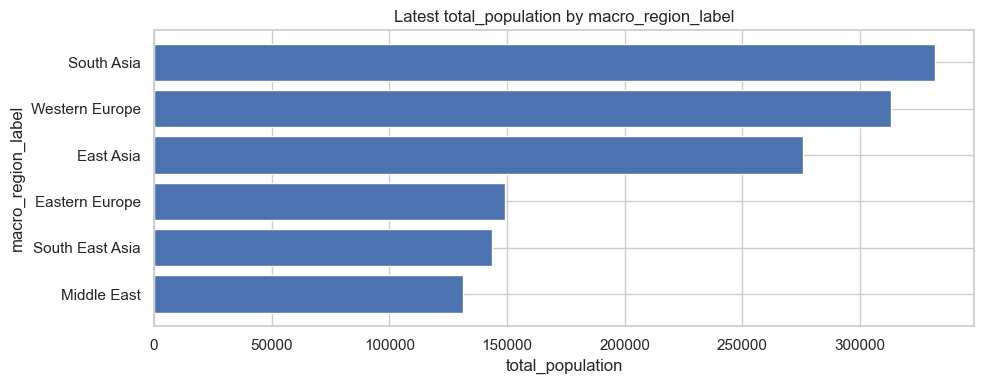

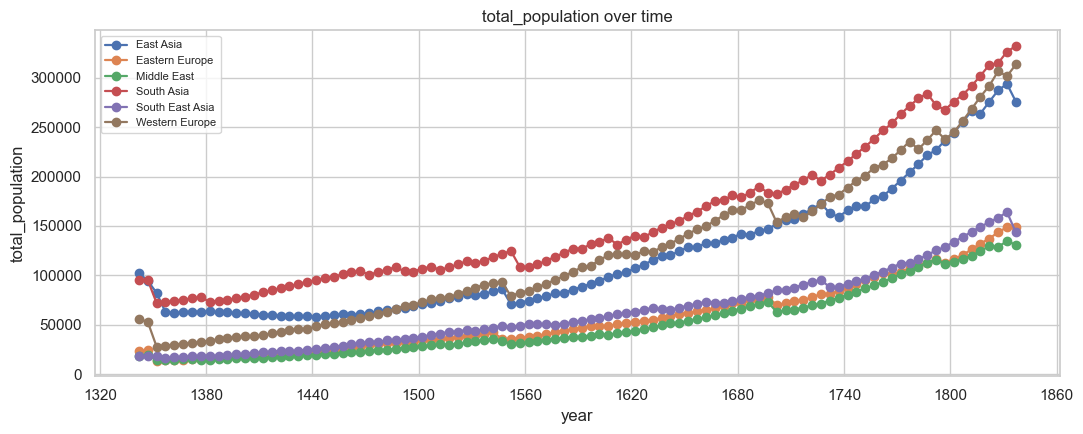

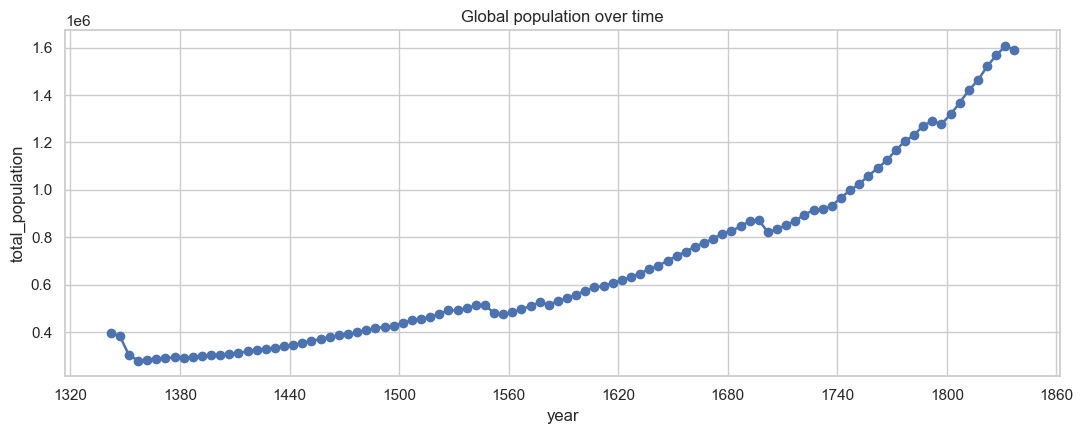

In [4]:
workbench.plot_population(population)


## Goods And Markets

In [5]:
goods = workbench.goods()
goods_global_ts = goods.global_time_series
market_scarcity = goods.scarcity
goods_imbalance = goods.imbalance
goods_imbalance_all = goods.goods_imbalance_all
market_flow_value = goods.flow_value
goods_global_ts, market_scarcity.head(TOP_N), market_flow_value.head(TOP_N)


(shape: (100, 12)
 ┌────────┬────────┬────────┬──────┬────────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┐
 │ date_s ┆ good_i ┆ good_l ┆ year ┆ supply ┆ deman ┆ stock ┆ mean_ ┆ media ┆ price ┆ price ┆ net   │
 │ ort    ┆ d      ┆ abel   ┆ ---  ┆ ---    ┆ d     ┆ pile  ┆ price ┆ n_pri ┆ _p10  ┆ _p90  ┆ ---   │
 │ ---    ┆ ---    ┆ ---    ┆ u16  ┆ f32    ┆ ---   ┆ ---   ┆ ---   ┆ ce    ┆ ---   ┆ ---   ┆ f32   │
 │ u32    ┆ str    ┆ str    ┆      ┆        ┆ f32   ┆ f32   ┆ f32   ┆ ---   ┆ f32   ┆ f32   ┆       │
 │        ┆        ┆        ┆      ┆        ┆       ┆       ┆       ┆ f32   ┆       ┆       ┆       │
 ╞════════╪════════╪════════╪══════╪════════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╡
 │ 134204 ┆ victua ┆ Victua ┆ 1342 ┆ 3484.7 ┆ 2134. ┆ 38715 ┆ 2.252 ┆ 2.012 ┆ 1.485 ┆ 3.125 ┆ 1350. │
 │ 01     ┆ ls     ┆ ls     ┆      ┆ 6123   ┆ 06713 ┆ .3476 ┆ 993   ┆ 69    ┆ 39    ┆ 36    ┆ 69409 │
 │        ┆        ┆        ┆      ┆        ┆ 9     ┆ 56    ┆   

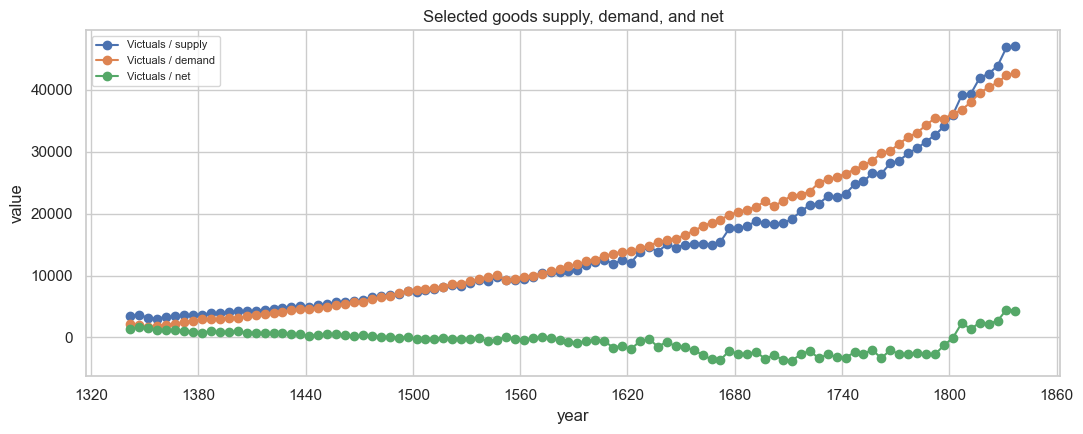

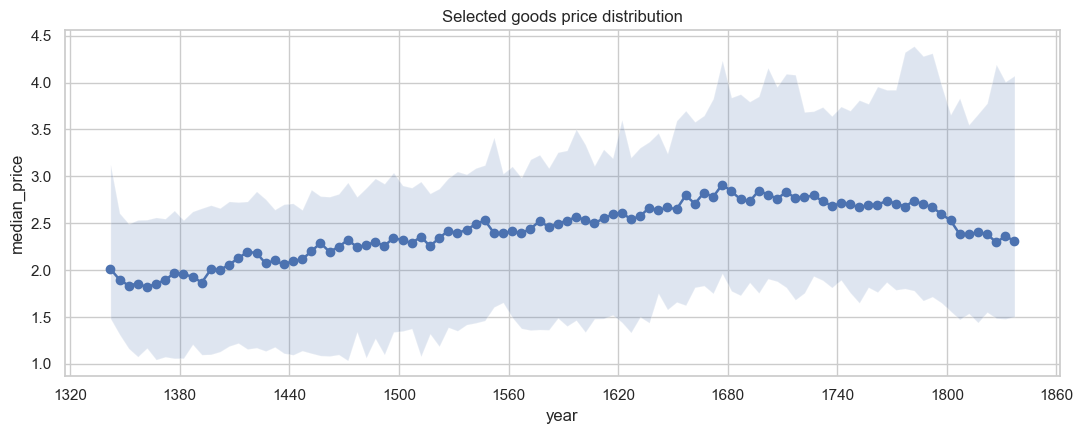

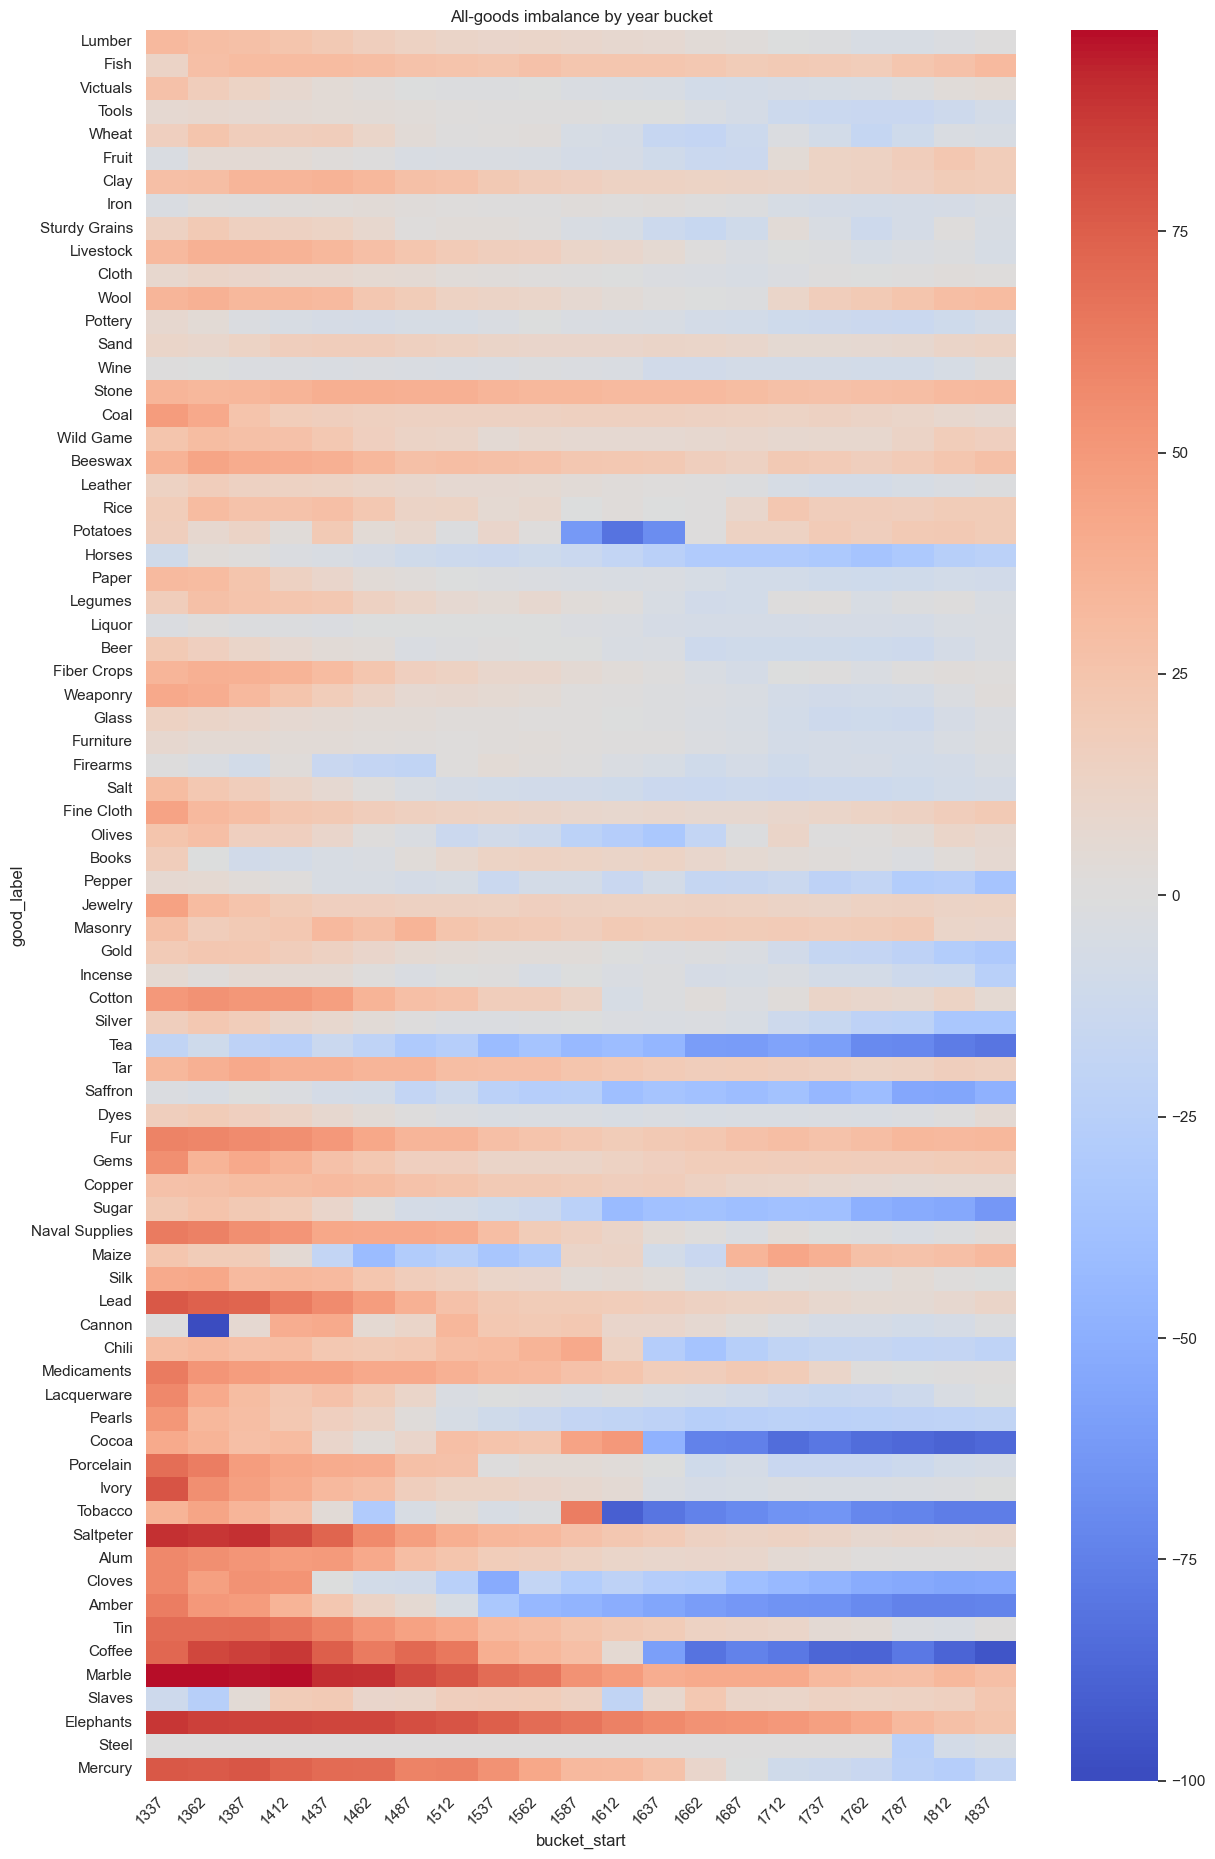

In [6]:
workbench.plot_goods(goods)


## Goods Source / Sink Flows

In [7]:
flows = workbench.flows()
source_breakdown = flows.source_breakdown
sink_breakdown = flows.sink_breakdown
source_ts = flows.source_time_series
sink_ts = flows.sink_time_series
good_consumption_latest = flows.good_consumption_latest
good_consumption_over_time = flows.good_consumption_over_time
source_breakdown, sink_breakdown, good_consumption_latest


(shape: (6, 3)
 ┌───────────────────┬─────────────────┬─────────────┐
 │ flow_table        ┆ market_label    ┆ amount      │
 │ ---               ┆ ---             ┆ ---         │
 │ str               ┆ str             ┆ f32         │
 ╞═══════════════════╪═════════════════╪═════════════╡
 │ production_method ┆ Genoa           ┆ 2722.318604 │
 │ production_method ┆ Cologne         ┆ 2510.952148 │
 │ production_method ┆ Prague          ┆ 1898.03125  │
 │ production_method ┆ Thăng Long      ┆ 1309.560791 │
 │ production_method ┆ Khambat         ┆ 1266.807739 │
 │ production_method ┆ Punamu'kwati'jk ┆ 1133.685791 │
 └───────────────────┴─────────────────┴─────────────┘,
 shape: (6, 3)
 ┌───────────────────┬──────────────┬─────────────┐
 │ flow_table        ┆ market_label ┆ amount      │
 │ ---               ┆ ---          ┆ ---         │
 │ str               ┆ str          ┆ f32         │
 ╞═══════════════════╪══════════════╪═════════════╡
 │ market_bucket     ┆ Cologne      ┆ 3330.474854

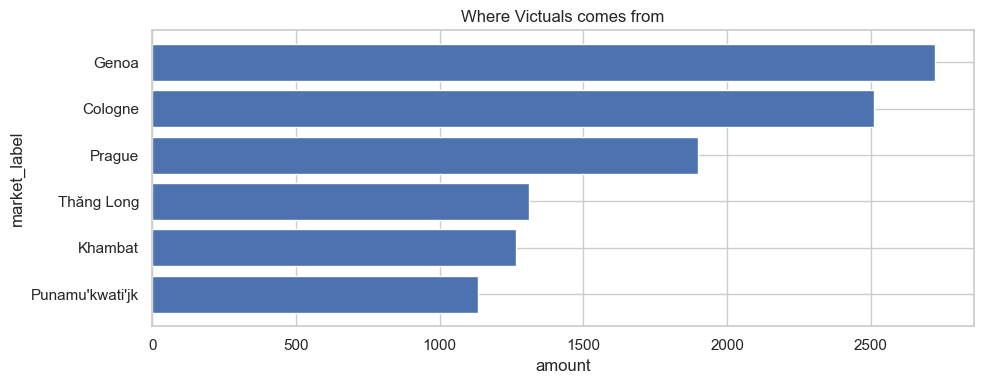

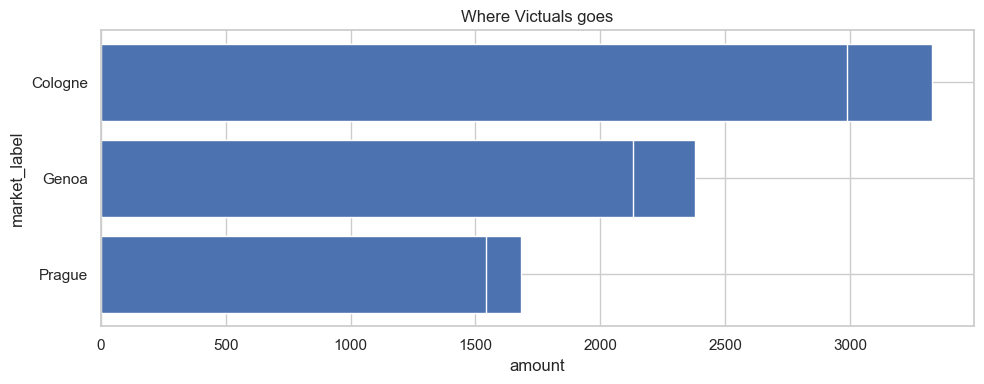

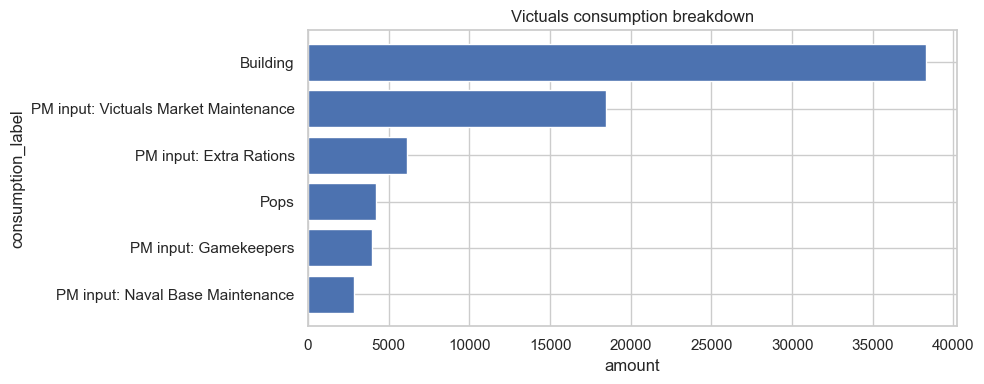

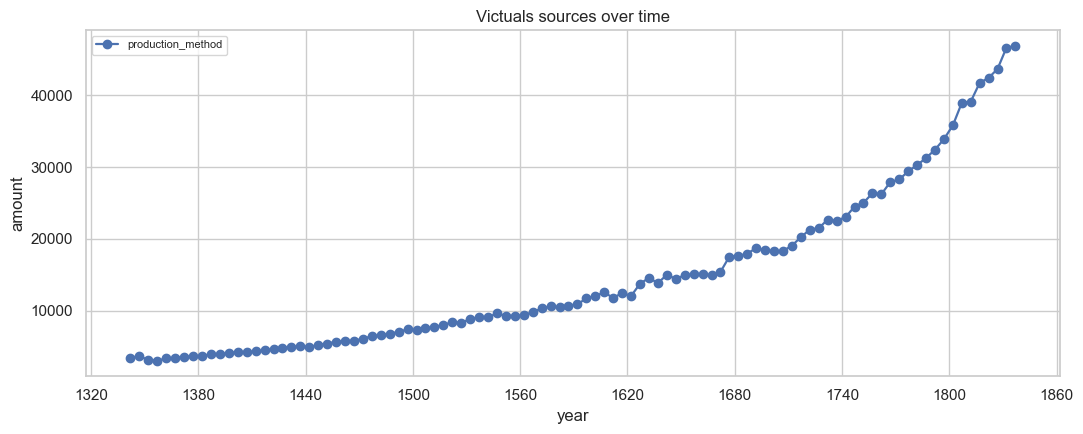

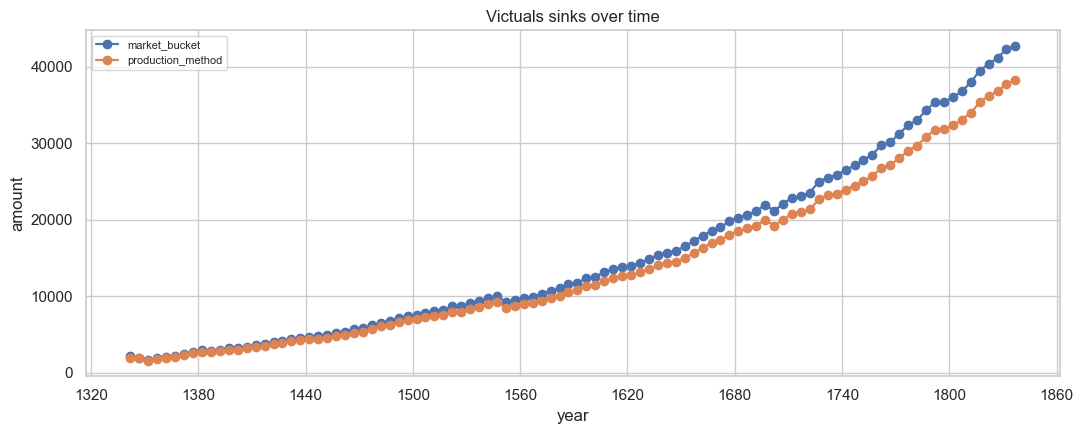

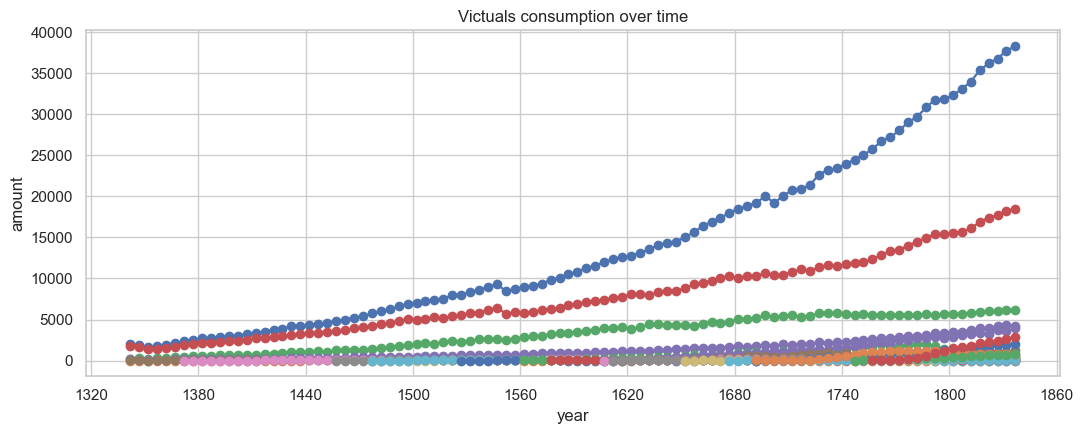

In [8]:
workbench.plot_flows(flows)


## Food Markets

In [9]:
food = workbench.food()
food_rank = food.rank
food_global = food.global_time_series
food_price_distribution = food.price_distribution
food_delta = food.delta
food_rank, food_delta, food_global


(shape: (6, 9)
 ┌───────────┬───────────┬──────┬───────────┬───────────┬──────────┬──────────┬──────────┬──────────┐
 │ market_id ┆ market_la ┆ food ┆ food_max  ┆ food_bala ┆ populati ┆ capacity ┆ food_pri ┆ food_fil │
 │ ---       ┆ bel       ┆ ---  ┆ ---       ┆ nce       ┆ on       ┆ ---      ┆ ce       ┆ l_ratio  │
 │ i64       ┆ ---       ┆ f32  ┆ f32       ┆ ---       ┆ ---      ┆ f32      ┆ ---      ┆ ---      │
 │           ┆ str       ┆      ┆           ┆ f32       ┆ f32      ┆          ┆ f32      ┆ f32      │
 ╞═══════════╪═══════════╪══════╪═══════════╪═══════════╪══════════╪══════════╪══════════╪══════════╡
 │ 199       ┆ Hiva Oa   ┆ 0.0  ┆ 1252.1469 ┆ 0.0       ┆ 2.77878  ┆ 2.46537  ┆ 0.12     ┆ null     │
 │           ┆           ┆      ┆ 73        ┆           ┆          ┆          ┆          ┆          │
 │ 182       ┆ Rapa Nui  ┆ 0.0  ┆ 1211.5780 ┆ 0.0       ┆ 1.52894  ┆ 2.30393  ┆ 0.12     ┆ null     │
 │           ┆           ┆      ┆ 03        ┆           ┆          

No rows


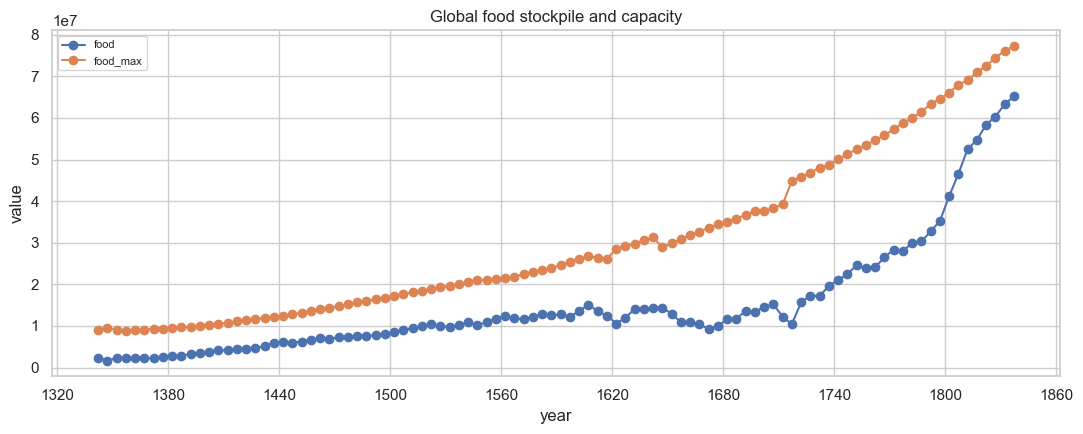

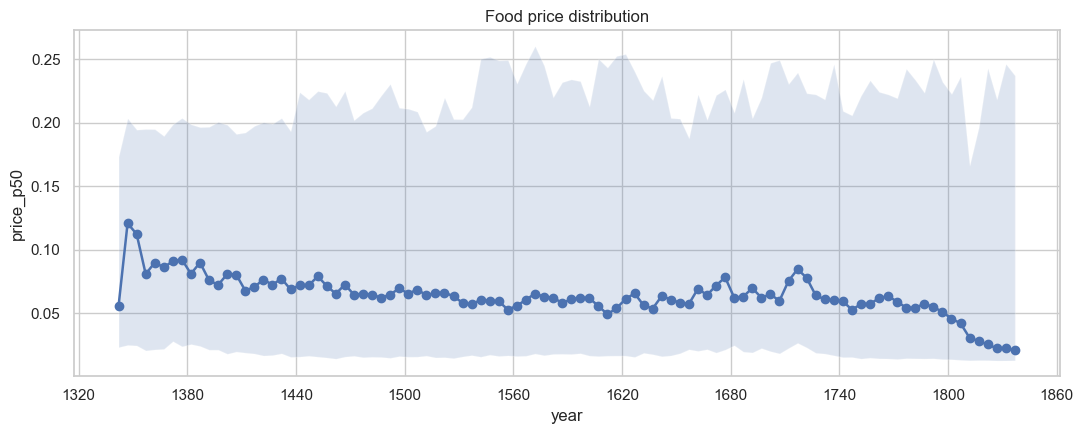

In [10]:
workbench.plot_food(food)


## Buildings And Production Methods

In [11]:
buildings = workbench.buildings()
building_latest = buildings.latest
building_ts = buildings.time_series
pm_adoption = buildings.pm_adoption
pm_preferences = buildings.pm_preferences
pm_regional_preferences_by_slot = buildings.pm_regional_preferences_by_slot
pm_slot_ts = buildings.pm_slot_time_series
pm_usage_by_slot_over_time = buildings.pm_usage_by_slot_over_time
pm_values = buildings.pm_values
building_latest.head(TOP_N), pm_regional_preferences_by_slot.head(TOP_N), pm_values.head(TOP_N)


(shape: (6, 3)
 ┌────────────────┬────────────────────┬────────┐
 │ building_label ┆ macro_region_label ┆ level  │
 │ ---            ┆ ---                ┆ ---    │
 │ str            ┆ str                ┆ f32    │
 ╞════════════════╪════════════════════╪════════╡
 │ Cookery        ┆ Western Europe     ┆ 1685.0 │
 │ Cookery        ┆ South Asia         ┆ 909.0  │
 │ Cookery        ┆ East Asia          ┆ 892.0  │
 │ Cookery        ┆ Eastern Europe     ┆ 604.0  │
 │ Cookery        ┆ South East Asia    ┆ 476.0  │
 │ Cookery        ┆ Middle East        ┆ 334.0  │
 └────────────────┴────────────────────┴────────┘,
 shape: (6, 7)
 ┌───────────────┬──────────────┬──────────────┬──────────────┬──────────────┬───────────┬──────────┐
 │ macro_region_ ┆ building_lab ┆ slot_label   ┆ production_m ┆ production_m ┆ buildings ┆ share    │
 │ label         ┆ el           ┆ ---          ┆ ethod_label  ┆ ethod_group_ ┆ ---       ┆ ---      │
 │ ---           ┆ ---          ┆ str          ┆ ---          ┆

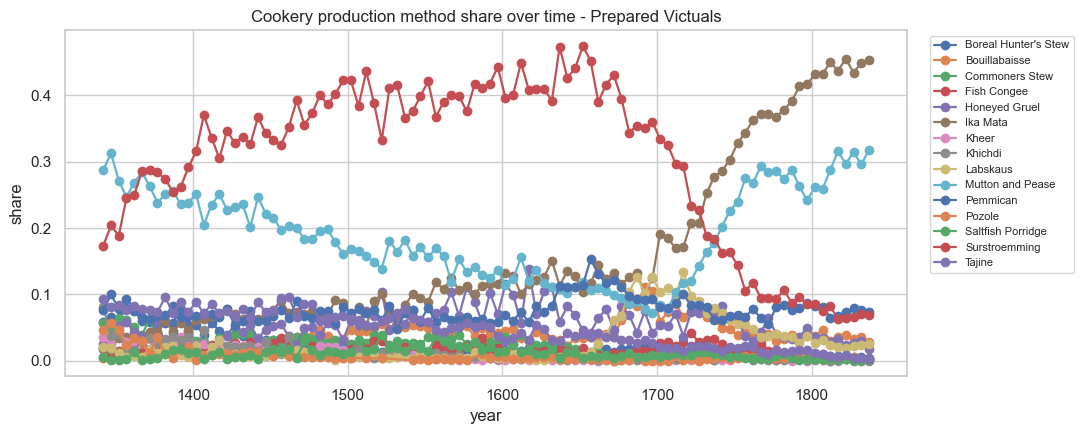

In [12]:
import matplotlib.pyplot as plt
import polars as pl
from IPython.display import display

SLOT_INDEX = 0
null_slot_rows = pm_slot_ts.filter(pl.col("production_method_group_index").is_null())
if null_slot_rows.height == pm_slot_ts.height:
    if SLOT_INDEX == 0:
        pm_slot_plot_ts = pm_slot_ts.with_columns(pl.col("slot_label").alias("_plot_slot_key"))
        slot_key = pm_slot_plot_ts.get_column("_plot_slot_key").drop_nulls().unique().sort().to_list()[0]
    else:
        pm_slot_plot_ts = pm_slot_ts.head(0).with_columns(pl.lit(None, dtype=pl.String).alias("_plot_slot_key"))
        slot_key = None
elif not null_slot_rows.is_empty():
    raise ValueError(
        "pm_slot_ts contains rows without production_method_group_index. "
        "Rerun the buildings cell or rebuild the notebook dataset; slot plots require resolved slot metadata."
    )
else:
    pm_slot_plot_ts = pm_slot_ts.with_columns(
        pl.col("production_method_group_index").cast(pl.String).alias("_plot_slot_key")
    )
    slot_key = str(SLOT_INDEX)

if slot_key is not None:
    slot_frame = pm_slot_plot_ts.filter(pl.col("_plot_slot_key") == slot_key).sort("year")

    if slot_frame.is_empty():
        raise ValueError(f"slot {slot_key}: no data")

    slot_name = (
        slot_frame.get_column("slot_label").drop_nulls().to_list() or [f"slot {slot_key}"]
    )[0]
    methods = slot_frame.get_column("production_method_label").unique().sort().to_list()

    fig, ax = plt.subplots(figsize=(11, 4.5))
    for method in methods:
        series = slot_frame.filter(pl.col("production_method_label") == method).sort("year")
        ax.plot(
            series["year"].to_list(),
            series["share"].to_list(),
            marker="o",
            linewidth=1.6,
            label=method,
        )
    ax.set_title(
        f"{workbench.building_label} production method share over time - {slot_name}"
    )
    ax.set_xlabel("year")
    ax.set_ylabel("share")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    fig.tight_layout()
    display(fig)
    plt.close(fig)


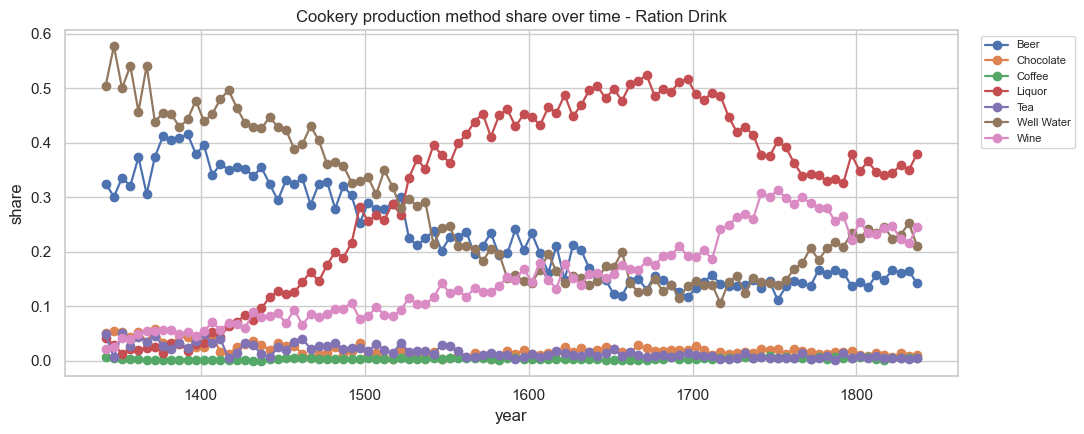

In [13]:
import matplotlib.pyplot as plt
import polars as pl
from IPython.display import display

SLOT_INDEX = 1
null_slot_rows = pm_slot_ts.filter(pl.col("production_method_group_index").is_null())
if null_slot_rows.height == pm_slot_ts.height:
    if SLOT_INDEX == 0:
        pm_slot_plot_ts = pm_slot_ts.with_columns(pl.col("slot_label").alias("_plot_slot_key"))
        slot_key = pm_slot_plot_ts.get_column("_plot_slot_key").drop_nulls().unique().sort().to_list()[0]
    else:
        pm_slot_plot_ts = pm_slot_ts.head(0).with_columns(pl.lit(None, dtype=pl.String).alias("_plot_slot_key"))
        slot_key = None
elif not null_slot_rows.is_empty():
    raise ValueError(
        "pm_slot_ts contains rows without production_method_group_index. "
        "Rerun the buildings cell or rebuild the notebook dataset; slot plots require resolved slot metadata."
    )
else:
    pm_slot_plot_ts = pm_slot_ts.with_columns(
        pl.col("production_method_group_index").cast(pl.String).alias("_plot_slot_key")
    )
    slot_key = str(SLOT_INDEX)

if slot_key is not None:
    slot_frame = pm_slot_plot_ts.filter(pl.col("_plot_slot_key") == slot_key).sort("year")

    if slot_frame.is_empty():
        raise ValueError(f"slot {slot_key}: no data")

    slot_name = (
        slot_frame.get_column("slot_label").drop_nulls().to_list() or [f"slot {slot_key}"]
    )[0]
    methods = slot_frame.get_column("production_method_label").unique().sort().to_list()

    fig, ax = plt.subplots(figsize=(11, 4.5))
    for method in methods:
        series = slot_frame.filter(pl.col("production_method_label") == method).sort("year")
        ax.plot(
            series["year"].to_list(),
            series["share"].to_list(),
            marker="o",
            linewidth=1.6,
            label=method,
        )
    ax.set_title(
        f"{workbench.building_label} production method share over time - {slot_name}"
    )
    ax.set_xlabel("year")
    ax.set_ylabel("share")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    fig.tight_layout()
    display(fig)
    plt.close(fig)


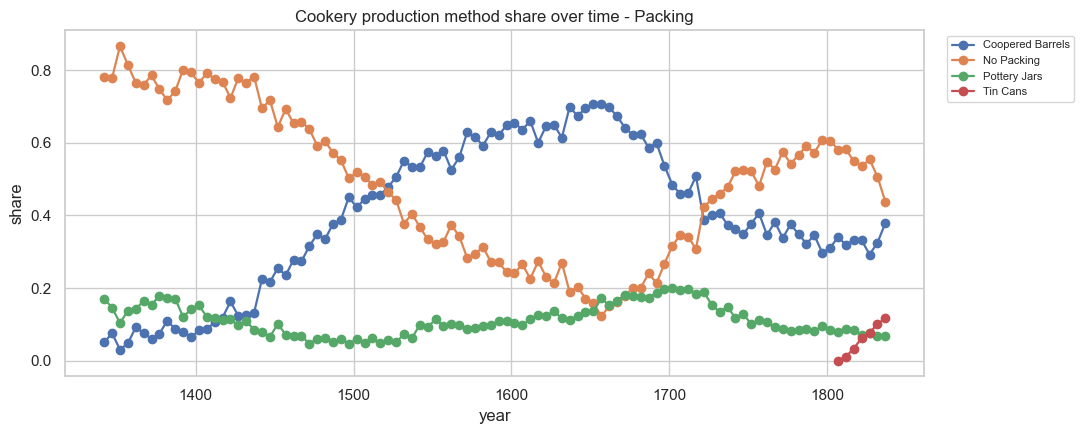

In [14]:
import matplotlib.pyplot as plt
import polars as pl
from IPython.display import display

SLOT_INDEX = 2
null_slot_rows = pm_slot_ts.filter(pl.col("production_method_group_index").is_null())
if null_slot_rows.height == pm_slot_ts.height:
    if SLOT_INDEX == 0:
        pm_slot_plot_ts = pm_slot_ts.with_columns(pl.col("slot_label").alias("_plot_slot_key"))
        slot_key = pm_slot_plot_ts.get_column("_plot_slot_key").drop_nulls().unique().sort().to_list()[0]
    else:
        pm_slot_plot_ts = pm_slot_ts.head(0).with_columns(pl.lit(None, dtype=pl.String).alias("_plot_slot_key"))
        slot_key = None
elif not null_slot_rows.is_empty():
    raise ValueError(
        "pm_slot_ts contains rows without production_method_group_index. "
        "Rerun the buildings cell or rebuild the notebook dataset; slot plots require resolved slot metadata."
    )
else:
    pm_slot_plot_ts = pm_slot_ts.with_columns(
        pl.col("production_method_group_index").cast(pl.String).alias("_plot_slot_key")
    )
    slot_key = str(SLOT_INDEX)

if slot_key is not None:
    slot_frame = pm_slot_plot_ts.filter(pl.col("_plot_slot_key") == slot_key).sort("year")

    if slot_frame.is_empty():
        raise ValueError(f"slot {slot_key}: no data")

    slot_name = (
        slot_frame.get_column("slot_label").drop_nulls().to_list() or [f"slot {slot_key}"]
    )[0]
    methods = slot_frame.get_column("production_method_label").unique().sort().to_list()

    fig, ax = plt.subplots(figsize=(11, 4.5))
    for method in methods:
        series = slot_frame.filter(pl.col("production_method_label") == method).sort("year")
        ax.plot(
            series["year"].to_list(),
            series["share"].to_list(),
            marker="o",
            linewidth=1.6,
            label=method,
        )
    ax.set_title(
        f"{workbench.building_label} production method share over time - {slot_name}"
    )
    ax.set_xlabel("year")
    ax.set_ylabel("share")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    fig.tight_layout()
    display(fig)
    plt.close(fig)
